In [150]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [151]:
with open("../data/raw_credit_applications.json") as f:
    data = json.load(f)

df = pd.json_normalize(data)
df.columns
df.head()

,_id,spending_behavior,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,...,financials.credit_history_months,financials.debt_to_income,financials.savings_balance,decision.loan_approved,decision.rejection_reason,loan_purpose,decision.interest_rate,decision.approved_amount,financials.annual_salary,notes
0,app_200,"[{'category': 'Shopping', 'amount': 480}, {'ca...",2024-01-15T00:00:00Z,Jerry Smith,jerry.smith17@hotmail.com,596-64-4340,192.168.48.155,Male,2001-03-09,10036,...,23,0.20,31212,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
1,app_037,"[{'category': 'Rent', 'amount': 608}, {'catego...",NaN,Brandon Walker,brandon.walker2@yahoo.com,425-69-4784,10.1.102.112,M,1992-03-31,10032,...,51,0.18,17915,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN
2,app_215,"[{'category': 'Rent', 'amount': 109}]",NaN,Scott Moore,scott.moore94@mail.com,370-78-5178,10.240.193.250,Male,1989-10-24,10075,...,41,0.21,37909,True,NaN,vacation,3.7,59000.0,NaN,NaN
3,app_024,"[{'category': 'Fitness', 'amount': 575}]",NaN,Thomas Lee,thomas.lee6@protonmail.com,194-35-1833,192.168.175.67,Male,1983-04-25,10077,...,70,0.35,0,True,NaN,NaN,4.3,34000.0,NaN,NaN
4,app_184,"[{'category': 'Entertainment', 'amount': 463}]",2024-01-15T00:00:00Z,Brian Rodriguez,brian.rodriguez86@aol.com,480-41-2475,172.29.125.105,M,1999-05-21,10080,...,14,0.23,31763,False,algorithm_risk_score,NaN,NaN,NaN,NaN,NaN


In [152]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 502 entries, 0 to 501
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   _id                               502 non-null    object 
 1   spending_behavior                 502 non-null    object 
 2   processing_timestamp              62 non-null     object 
 3   applicant_info.full_name          502 non-null    object 
 4   applicant_info.email              502 non-null    object 
 5   applicant_info.ssn                497 non-null    object 
 6   applicant_info.ip_address         497 non-null    object 
 7   applicant_info.gender             501 non-null    object 
 8   applicant_info.date_of_birth      501 non-null    object 
 9   applicant_info.zip_code           501 non-null    object 
 10  financials.annual_income          497 non-null    object 
 11  financials.credit_history_months  502 non-null    int64  
 12  financia

In [153]:
sensitive_data = {
    "Attribute": [
        "applicant_info.gender",
        "applicant_info.date_of_birth",
        "applicant_info.zip_code",
        "applicant_info.ssn",
        "applicant_info.email",
        "applicant_info.ip_address"
    ],
    "Category": [
        "Sensitive attribute",
        "Sensitive attribute",
        "Sensitive attribute (proxy)",
        "Personally Identifiable Information (PII)",
        "Personally Identifiable Information (PII)",
        "Personally Identifiable Information (PII)"
    ],
    "Risk Type": [
        "Gender discrimination",
        "Age discrimination",
        "Proxy discrimination",
        "Identity exposure",
        "Personal identification",
        "User tracking"
    ]
}

sensitive_table = pd.DataFrame(sensitive_data)

sensitive_table

,Attribute,Category,Risk Type
0,applicant_info.gender,Sensitive attribute,Gender discrimination
1,applicant_info.date_of_birth,Sensitive attribute,Age discrimination
2,applicant_info.zip_code,Sensitive attribute (proxy),Proxy discrimination
3,applicant_info.ssn,Personally Identifiable Information (PII),Identity exposure
4,applicant_info.email,Personally Identifiable Information (PII),Personal identification
5,applicant_info.ip_address,Personally Identifiable Information (PII),User tracking


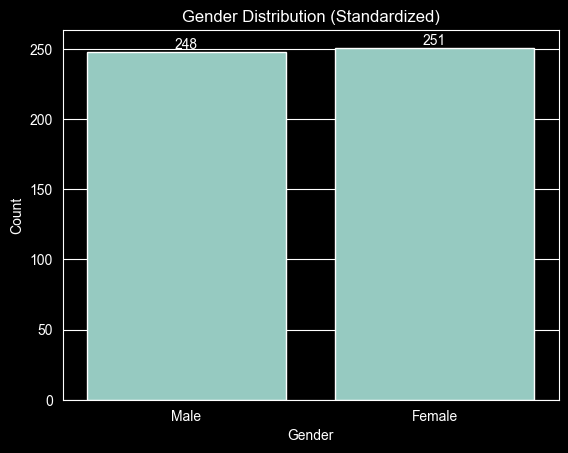

In [154]:
# Clean gender values
g = (
    df["applicant_info.gender"]
    .astype(str)
    .str.strip()
    .str.lower()
)

# Map values to Male/Female
df["gender_clean"] = g.map({
    "m": "Male",
    "male": "Male",
    "1": "Male",
    "f": "Female",
    "female": "Female",
    "2": "Female"
})

# Keep only valid values
df_gender = df[df["gender_clean"].isin(["Male", "Female"])]

# Plot
ax = sns.countplot(x="gender_clean", data=df_gender)

plt.title("Gender Distribution (Standardized)")
plt.xlabel("Gender")
plt.ylabel("Count")

for p in ax.patches:
    ax.annotate(
        int(p.get_height()),
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha="center",
        va="bottom"
    )

plt.show()

In [155]:
# Approval rate by gender
approval_by_gender = df.groupby("gender_clean")["decision.loan_approved"].mean()

female_rate = approval_by_gender.get("Female", float("nan"))
male_rate   = approval_by_gender.get("Male", float("nan"))

print("=== Approval Rate by Gender ===")
print(approval_by_gender)

print("\n=== Approval Rate (percent) ===")
print(f"Female approval rate: {female_rate:.4f} ({female_rate*100:.2f}%)")
print(f"Male approval rate:   {male_rate:.4f} ({male_rate*100:.2f}%)")

# Difference
diff_pp = (male_rate - female_rate) * 100
print("\n=== Approval Gap ===")
print(f"Difference (Male - Female): {diff_pp:.2f} percentage points")

# Disparate Impact Ratio
DIR = female_rate / male_rate

print("\n=== Disparate Impact Ratio (DIR) ===")
print(f"DIR = {DIR:.3f}")

# Governance interpretation
print("\n=== Fairness Interpretation ===")

if DIR < 0.8:
    print("⚠️ The DIR is below the 0.8 fairness threshold.")
    print("This may indicate potential gender bias in the loan approval process.")
else:
    print("The DIR is above the 0.8 fairness threshold.")
    print("No significant disparate impact detected based on this metric.")

=== Approval Rate by Gender ===
gender_clean
Female    0.505976
Male      0.657258
Name: decision.loan_approved, dtype: float64

=== Approval Rate (percent) ===
Female approval rate: 0.5060 (50.60%)
Male approval rate:   0.6573 (65.73%)

=== Approval Gap ===
Difference (Male - Female): 15.13 percentage points

=== Disparate Impact Ratio (DIR) ===
DIR = 0.770

=== Fairness Interpretation ===
⚠️ The DIR is below the 0.8 fairness threshold.
This may indicate potential gender bias in the loan approval process.


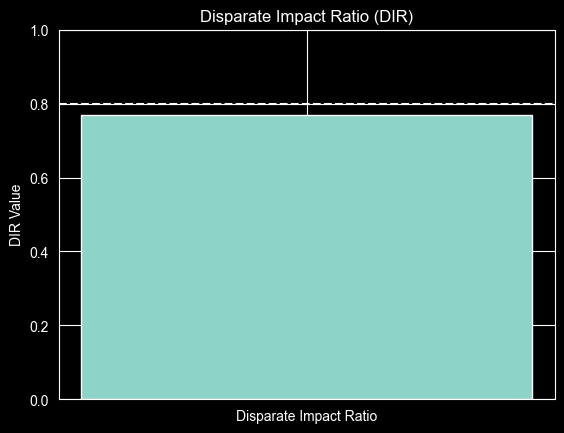

In [156]:
DIR = female_rate / male_rate

plt.figure()

plt.bar(["Disparate Impact Ratio"], [DIR])

plt.axhline(0.8, linestyle="--")

plt.title("Disparate Impact Ratio (DIR)")
plt.ylabel("DIR Value")

plt.ylim(0,1)

plt.show()

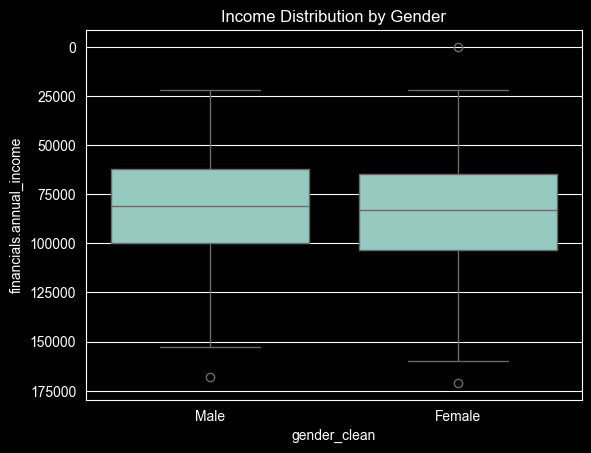

In [157]:
sns.boxplot(
    x="gender_clean",
    y="financials.annual_income",
    data=df
)

plt.title("Income Distribution by Gender")
plt.show()